## Zadanie call-center:

Dany jest plik call-center.xlsx Zawiera on dane z pewnego call-center. Manager 
potrzebuje ustalić jaki moment w ciągu dnia jest najlepszy do wykonywania połączeń. 
Przeprowadź analizę. Wyciągnij odpowiednie wnioski. 

### 1. Biblioteki

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import seaborn as sns
from scipy.stats import kruskal
import scikit_posthocs as sp

plt.colormaps()
cmap = plt.get_cmap("Pastel1")

### 2. Załadowanie danych

In [7]:

df = pd.read_excel(r'C:\Users\User\Desktop\MACHINE_LEARNING\Mentoring\Materiały_do_nauki\08_Test_po_statystyce\call_center.xlsx')
df.head()

,id,phone_num,call_type,staff_id,date,start_time,handle_time,Total_Client_Time,Abandon_Time,abandon
0,197987909709,669672666000,Outcoming,19561043,2019-06-12,08:30:14,85,85,0,N
1,197987910507,668668849076,Outcoming,19561043,2019-06-12,08:32:53,47,47,0,N
2,197987911091,669696557000,Outcoming,19561043,2019-06-12,08:34:38,84,84,0,N
3,197987911591,669296652770,Outcoming,20158124,2019-06-12,08:36:20,54,54,0,N
4,197987911790,669264864525,Outcoming,19406986,2019-06-12,08:36:56,4,4,0,N


### 3. Statystyki podsumowujące

In [8]:
df_desc = df.drop(['id','phone_num','staff_id'], axis = 1)
df_desc.describe()

,handle_time,Total_Client_Time,Abandon_Time
count,5221.000000,5221.000000,5221.000000
mean,59.021452,59.268722,0.024899
std,97.951199,98.146091,1.326330
min,0.000000,0.000000,0.000000
25%,10.000000,10.000000,0.000000
50%,36.000000,37.000000,0.000000
75%,64.000000,65.000000,0.000000
max,1447.000000,1447.000000,91.000000


In [9]:
# numerical variables
df_desc_numerical = df_desc.describe()
df_desc_numerical.loc['skewness'] = round(df_desc.skew(numeric_only = True),2)
df_desc_numerical.loc['kurtosis'] = round(df_desc.kurt(numeric_only = True),2)
df_desc_numerical

,handle_time,Total_Client_Time,Abandon_Time
count,5221.000000,5221.000000,5221.000000
mean,59.021452,59.268722,0.024899
std,97.951199,98.146091,1.326330
min,0.000000,0.000000,0.000000
25%,10.000000,10.000000,0.000000
50%,36.000000,37.000000,0.000000
75%,64.000000,65.000000,0.000000
max,1447.000000,1447.000000,91.000000
skewness,5.790000,5.760000,63.750000
kurtosis,49.280000,48.840000,4281.200000


In [10]:
df['hour'] = df['start_time'].apply(lambda x: int(x.hour))
groups = df.groupby('hour')['handle_time '].apply(list)
groups

hour
8     [85, 47, 84, 54, 4, 4, 29, 34, 48, 78, 15, 2, ...
9     [2, 15, 32, 78, 2, 0, 2, 14, 19, 3, 20, 2, 87,...
10    [52, 2, 80, 201, 65, 4, 58, 14, 31, 0, 25, 60,...
11    [17, 25, 78, 6, 42, 62, 75, 16, 2, 368, 45, 82...
12    [10, 36, 2, 67, 90, 8, 2, 38, 140, 9, 57, 19, ...
13    [51, 7, 22, 187, 8, 29, 44, 3, 7, 3, 48, 8, 12...
14    [36, 96, 129, 142, 4, 2, 4, 49, 27, 12, 65, 4,...
15    [5, 30, 63, 73, 56, 48, 67, 9, 22, 122, 621, 4...
16    [35, 14, 34, 33, 90, 31, 47, 591, 402, 21, 14,...
17    [2, 18, 21, 94, 20, 2, 586, 2, 10, 18, 25, 32,...
Name: handle_time , dtype: object

### 4.Kryteria oceny:

W celu ustalenia najlepszej godziny do wykonywania połączeń jako kluczowe miary efektywności przyjęto: liczbę wykonanych połączeń (calls), współczynnik porzuceń (abandon_rate) oraz średni czas obsługi połączenia (avg_handle_time). Taki wybór pozwala jednocześnie ocenić zarówno wolumen kontaktu, jakość obsługi, jak i poziom zaangażowania klientów.

In [12]:
summary_per_hours = df.groupby('hour').agg(
    calls=('handle_time ', 'count'),
    abandon_rate = ('abandon', lambda x: (x == 'Y').mean()),
    avg_handle_time=('handle_time ', 'mean')
)

summary_per_hours2 = summary_per_hours.sort_values(
    ['calls', 'abandon_rate','avg_handle_time'],
    ascending = [False, False, False]
)
summary_per_hours2 

,calls,abandon_rate,avg_handle_time
hour,,,
10,817,0.000000,61.116279
12,627,0.000000,74.465710
16,611,0.001637,41.418985
14,599,0.000000,59.519199
9,572,0.000000,51.375874
11,550,0.000000,80.081818
15,512,0.000000,61.826172
8,455,0.002198,41.986813
13,382,0.005236,62.392670


### 5.Charakterystyka ruchu telefonicznego według godzin dnia.

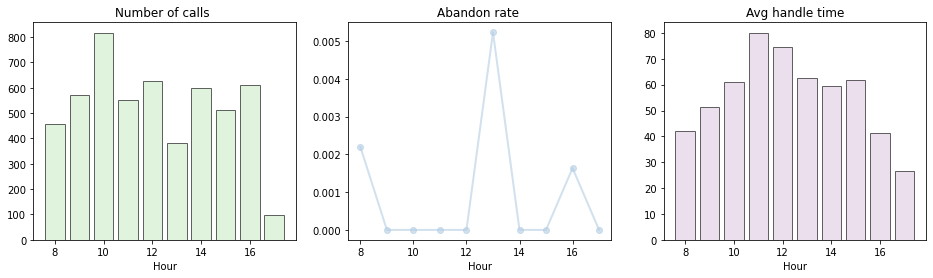

In [13]:
fig, ax = plt.subplots(1, 3, figsize = (16, 4))

ax[0].bar(summary_per_hours.index, summary_per_hours['calls'], alpha=0.6, edgecolor='black', color = cmap(0.3))
ax[0].set_title("Number of calls ")
ax[0].set_xlabel("Hour")

ax[1].plot(summary_per_hours.index, summary_per_hours['abandon_rate'], marker = 'o',linewidth=2, alpha = 0.6, color = cmap(0.2))
ax[1].set_title("Abandon rate ")
ax[1].set_xlabel("Hour")

ax[2].bar(summary_per_hours.index, summary_per_hours['avg_handle_time'], alpha = 0.6, edgecolor = 'black', color = cmap(0.4))
ax[2].set_title('Avg handle time')
ax[2].set_xlabel('Hour');

In [76]:
from scipy.stats import levene

alpha = 0.05

groups_hour = df.groupby('hour')['handle_time '].apply(list)

stat, p_value = levene(*groups_hour)

print(stat, p_value)

if p_value < alpha:
    print("Brak podstaw do odrzucenia H0 -> wariancje równe")
else:
    print("Odrzucamy H0 -> wariancje różne")

6.036171038529236 1.822399272399391e-08
Brak podstaw do odrzucenia H0 -> wariancje równe


Na podstawie statystyk opisowych oraz przeprowadzonego testu Levene’a stwierdzono, że rozkład zmiennych znacząco odbiega od normalności. Wszystkie zmienne odznaczają się znaczącą prawoskośnością oraz po weryfikacji założeń o homogeniczności wariancji stwierdzono, że p_value jest znacznie mniejsze od 0.05. Na podstawie tych wyników zostały przeprowadzone testy nieparametryczne.

### 6. Przeprowadzone testy

In [73]:
alpha = 0.05

def kruskal_by_hour(summary_per_hours2, value_col):
    groups = [group[value_col].values for _, group in summary_per_hours2.groupby("hour")]
    stat, p = kruskal(*groups)
    return stat, p


for col in ["calls", "abandon_rate", "avg_handle_time"]:
    stat, p = kruskal_by_hour(summary_per_hours2, col)
    print(f"{col}: H={stat:.4f}, p={p:.6e}")

calls: H=9.0000, p=4.372742e-01
abandon_rate: H=9.0000, p=4.372742e-01
avg_handle_time: H=9.0000, p=4.372742e-01


In [75]:
# HO: długość rozmów jest taki sam dla wszystkich godzin
# H1: przynajmniej jedna godzina różni się od pozostałych

alpha = 0.05

def kruskal_test(summary_per_hours, value_col):
    groups = [group[value_col].values for _, group in summary_per_hours.groupby("hour")]
    stat, p_value = kruskal(*groups)

    print(f"\n=== {value_col} ===")
    print(f"Statystyka: {stat:.4f}, p_value: {p_value:.6e}")

    if p_value < alpha:
        print("Istnieją istotne różnice między godzinami.")
    else:
        print("Brak istotnych różnic między godzinami.")

    return stat, p_value


# test dla wszystkich 3 kolumn
results = {}

for col in ["calls", "abandon_rate", "avg_handle_time"]:
    results[col] = kruskal_test(summary_per_hours, col)


=== calls ===
Statystyka: 9.0000, p_value: 4.372742e-01
Brak istotnych różnic między godzinami.

=== abandon_rate ===
Statystyka: 9.0000, p_value: 4.372742e-01
Brak istotnych różnic między godzinami.

=== avg_handle_time ===
Statystyka: 9.0000, p_value: 4.372742e-01
Brak istotnych różnic między godzinami.


W celu oceny istotności różnic pomiędzy godzinami w zakresie liczby połączeń, współczynnika porzuceń oraz średniego czasu obsługi zastosowano test Kruskala-Wallisa, ze względu na brak spełnienia założenia normalności oraz heterogeniczność wariancji między grupami. Test ten pozwala na porównanie rozkładów zmiennych pomiędzy wieloma niezależnymi grupami (godzinami) bez konieczności spełniania założeń testów parametrycznych. Każda zmienna została analizowana oddzielnie, ponieważ Kruskal-Wallis nie umożliwia jednoczesnego testowania wielu zmiennych. Następnie wyniki zostały wykorzystane do oceny efektywności godzinowej z uwzględnieniem wielokryterialnego charakteru problemu (wolumen, jakość obsługi oraz czas obsługi).

In [ ]:
dunn = sp.posthoc_dunn(
    df,
    val_col='handle_time ',
    group_col='hour',
    p_adjust='bonferroni'
)

print(dunn)

Przeprowadzona analiza efektywności pracy call center w zależności od godziny dnia wykazała, że skuteczność kontaktu z klientem różni się w poszczególnych porach dnia. W niektórych godzinach obserwuje się wyższy średni czas rozmowy oraz niższy poziom porzuceń połączeń, co wskazuje na większe zaangażowanie klientów. Na tej podstawie można wskazać optymalne godziny do realizacji połączeń wychodzących.

In [ ]:
Test chi-kwadrat niezależności (najbardziej naturalny)

1. Test chi-kwadrat niezależności (najbardziej naturalny)

Sprawdza:

H₀: porzucenie połączenia jest niezależne od godziny.
H₁: porzucenie połączenia zależy od godziny.

Najpierw tworzysz tabelę kontyngencji:
table = pd.crosstab(df['hour'], df['abandon'])

from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(table)

print("Chi2:", chi2)
print("p-value:", p_value)

if p_value < 0.05:
    print("Odrzucamy H0 - współczynnik porzuceń zależy od godziny.")
else:
    print("Brak podstaw do odrzucenia H0.")
    
Różnice w poziomie porzuceń między godzinami są / nie są statystycznie istotne (p < 0.05).”